**Table of contents**<a id='toc0_'></a>

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import time
from collections import namedtuple

import numpy as np
import numba as nb
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

from consav.grids import equilogspace
from consav.markov import log_rouwenhorst
from consav.linear_interp import interp_1d, interp_1d_vec

# Simulation and aggregation

The EGM gives us policy functions: what *one* household does in every state. To close the model in the next
lecture we need aggregates: total savings $A_t^{hh}$ and total consumption $C_t^{hh}$ across *all* households.
Those depend on how many households sit in each state, that is, on the distribution over $(z_t, a_{t-1})$.

This notebook simulates that distribution forward in two ways:

1. **Monte Carlo:** simulate a large sample of households and average.
2. **The histogram method** (Young, 2010): iterate on the distribution itself, as an array of probabilities.

Then we aggregate. The forward step we end up with, `simulate_hh_forwards`, is the second half of the household
block in `GEModelTools`; the first half, `solve_hh_backwards`, we built in the previous notebook.

## The model

Exactly the model of the previous notebook, solved with the same EGM code, here condensed into one cell.

In [2]:
Parameters = namedtuple('Parameters',
    'beta sigma r w rho_z sigma_psi Nz Na a_min a_max a_grid z_grid z_trans z_ergodic')

def setup():
    """ baseline parameters """

    # preferences
    beta = 0.96
    sigma = 2.0

    # prices
    r = 0.02
    w = 1.0

    # income
    rho_z = 0.95
    sigma_psi = 0.10
    Nz = 7
    z_grid,z_trans,z_ergodic,_,_ = log_rouwenhorst(rho_z,sigma_psi,Nz)

    # grids
    Na = 300
    a_min = 0.0
    a_max = 100.0
    a_grid = equilogspace(a_min,a_max,Na)

    return Parameters(beta,sigma,r,w,rho_z,sigma_psi,Nz,Na,a_min,a_max,a_grid,z_grid,z_trans,z_ergodic)

@nb.njit(parallel=True)
def solve_hh_backwards(par,z_trans,r,w,vbeg_a_plus,vbeg_a,a,c):
    """ solve backwards with vbeg_a from previous iteration (here vbeg_a_plus) """

    # a. solve step
    for i_z in nb.prange(par.Nz):

        c_endo = (par.beta*vbeg_a_plus[i_z])**(-1/par.sigma)
        a_endo = (c_endo + par.a_grid - w*par.z_grid[i_z])/(1+r)
        interp_1d_vec(a_endo,par.a_grid,par.a_grid,a[i_z])
        a[i_z,:] = np.fmax(a[i_z,:],0.0)
        c[i_z] = par.a_grid*(1+r) + w*par.z_grid[i_z] - a[i_z]

    # b. expectation step
    v_a = (1+r)*c**(-par.sigma)
    vbeg_a[:] = z_trans@v_a

def solve_hh_ss(par,r,w,max_iter=10_000,tol=1e-10):
    """ solve the household problem in the infinite horizon """

    # a. allocate
    vbeg_a = np.zeros((par.Nz,par.Na))
    a = np.zeros((par.Nz,par.Na))
    c = np.zeros((par.Nz,par.Na))

    # b. initial guess: a(z,a_) = a_, so consumption is the annuity value
    c_guess = r*par.a_grid[np.newaxis,:] + w*par.z_grid[:,np.newaxis]
    vbeg_a_plus = par.z_trans@((1+r)*c_guess**(-par.sigma))

    # c. iterate
    for it in range(max_iter):

        solve_hh_backwards(par,par.z_trans,r,w,vbeg_a_plus,vbeg_a,a,c)

        if np.max(np.abs(vbeg_a-vbeg_a_plus)) < tol: break
        vbeg_a_plus[:] = vbeg_a

    return c,a,vbeg_a

par = setup()
c,a,vbeg_a = solve_hh_ss(par,par.r,par.w)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Monte Carlo

The direct approach. Simulate $N$ households:

- **Initial state:** $a_{i,-1} = 0$ and $z_{i,-1}$ drawn from the ergodic distribution.
- **Each period:** draw $z_{it}$ given $z_{it-1}$ from the transition matrix, then read savings off the policy
  function, $a_{it} = a^*(z_{it}, a_{it-1})$, with linear interpolation.

After enough periods the cross-section $\{z_{it}, a_{it}\}_{i=0}^{N-1}$ no longer changes (as a distribution):
it has converged to the *stationary distribution*. Aggregates are then sample averages, e.g.
$A^{hh}_t = \frac{1}{N}\sum_i a_{it}$, and the law of large numbers says they converge to the truth as
$N \rightarrow \infty$.

### One household, step by step

Before writing the function, do it by hand for a single household.
Start at $a_{-1} = 0$ with productivity drawn from the ergodic distribution.

In [3]:
np.random.seed(1917)

a_lag = 0.0
i_z = np.random.choice(par.Nz,p=par.z_ergodic)
print(f'initial state: a_lag = {a_lag}, i_z = {i_z} (z = {par.z_grid[i_z]:.2f})')

initial state: a_lag = 0.0, i_z = 2 (z = 0.73)


Each period has two steps.

**1. Draw the new productivity state:** 
- Given $i_z$, the next state is drawn from row $i_z$ of the transition matrix.
- The way to draw from a discrete distribution with one uniform random number is to compare it with the *cumulative* probabilities: the new state is the first one whose cumulative probability exceeds the draw.
- `np.searchsorted` does exactly that.

In [4]:
z_trans_cumsum = np.cumsum(par.z_trans,axis=1)
print(z_trans_cumsum)
print('cumulative probabilities from i_z:',np.round(z_trans_cumsum[i_z],3))

[[8.59068301e-01 9.91232655e-01 9.99704729e-01 9.99994373e-01
  9.99999943e-01 1.00000000e+00 1.00000000e+00]
 [2.20273923e-02 8.83919718e-01 9.94201501e-01 9.99853264e-01
  9.99998134e-01 9.99999990e-01 1.00000000e+00]
 [5.64804932e-04 4.46775183e-02 9.08266487e-01 9.96549880e-01
  9.99941681e-01 9.99999629e-01 1.00000000e+00]
 [1.44821777e-05 1.71001099e-03 6.79225562e-02 9.32077444e-01
  9.98289989e-01 9.99985518e-01 1.00000000e+00]
 [3.71337891e-07 5.83190918e-05 3.45011963e-03 9.17335132e-02
  9.55322482e-01 9.99435195e-01 1.00000000e+00]
 [9.52148438e-09 1.86645508e-06 1.46735840e-04 5.79849854e-03
  1.16080282e-01 9.77972608e-01 1.00000000e+00]
 [2.44140625e-10 5.73730469e-08 5.62744141e-06 2.95270996e-04
  8.76734497e-03 1.40931699e-01 1.00000000e+00]]
cumulative probabilities from i_z: [0.001 0.045 0.908 0.997 1.    1.    1.   ]


In [5]:
u = np.random.random()
print(u)
i_z = np.searchsorted(z_trans_cumsum[i_z],u)
print(f'draw u = {u:.3f}, so the new state is i_z = {i_z} (z = {par.z_grid[i_z]:.2f})')

0.20789496806883712
draw u = 0.208, so the new state is i_z = 2 (z = 0.73)


**2. Read savings off the policy function.** $a_t = a^{\ast}(z_t,a_{t-1})$, interpolated between grid points.

In [6]:
a_lag = interp_1d(par.a_grid,a[i_z],a_lag)
print(f'end-of-period assets: a = {a_lag:.4f}')

end-of-period assets: a = 0.0000


That is one period. Repeat it $T$ times and the household's assets bounce around their buffer-stock target, as in notebook 03.

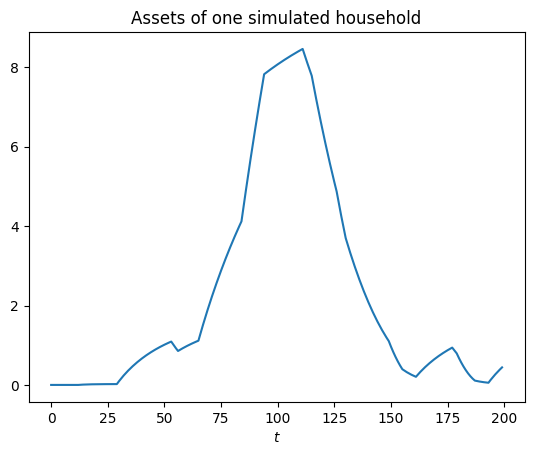

In [7]:
T_sim = 200
a_sim_one = np.zeros(T_sim)

for t in range(T_sim):
    i_z = np.searchsorted(z_trans_cumsum[i_z],np.random.random())
    a_lag = interp_1d(par.a_grid,a[i_z],a_lag)
    a_sim_one[t] = a_lag

plt.plot(a_sim_one)
plt.title('Assets of one simulated household')
plt.xlabel('$t$')
plt.show()

### Many households

Now the same for $N$ households at once, in a compiled function: the loop over households goes inside the loop over time, and each period we store the cross-sectional mean of assets.
`run_mc` allocates, draws the initial states and calls it.

In [8]:
@nb.njit
def simulate_mc(par,a_pol,z_trans_cumsum,i_z,a_sim,A_t):
    """ simulate the panel forward, storing aggregate assets per period """

    N = a_sim.size
    T_sim = A_t.size

    for t in range(T_sim):
        for i in range(N):
            i_z[i] = np.searchsorted(z_trans_cumsum[i_z[i]],np.random.random())
            a_sim[i] = interp_1d(par.a_grid,a_pol[i_z[i]],a_sim[i])
        A_t[t] = np.mean(a_sim)

def run_mc(par,a_pol,N,T_sim,seed=1917):
    """ allocate, draw the initial state and simulate """

    np.random.seed(seed)
    z_trans_cumsum = np.cumsum(par.z_trans,axis=1)
    i_z = np.random.choice(par.Nz,size=N,p=par.z_ergodic)
    a_sim = np.zeros(N)
    A_t = np.zeros(T_sim)
    simulate_mc(par,a_pol,z_trans_cumsum,i_z,a_sim,A_t)

    return i_z,a_sim,A_t

simulation time: 1.3 secs


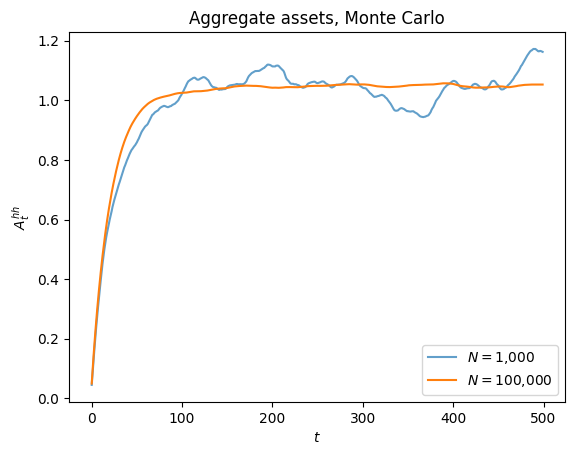

In [9]:
T_sim = 500

t0 = time.time()
i_z_small,a_small,A_t_small = run_mc(par,a,1_000,T_sim)
i_z_sim,a_sim,A_t = run_mc(par,a,100_000,T_sim)
print(f'simulation time: {time.time()-t0:.1f} secs')

plt.plot(A_t_small,label='$N = 1{,}000$',alpha=0.7)
plt.plot(A_t,label='$N = 100{,}000$')
plt.title('Aggregate assets, Monte Carlo')
plt.xlabel('$t$')
plt.ylabel('$A_t^{hh}$')
plt.legend()
plt.savefig('figs/sim_mc_A.pdf')
plt.show()

## The histogram method

- Young (2010): stop tracking households, track *probability mass*.
- The distribution becomes an array $\boldsymbol{D}$ over the grids $\mathcal{G}_z \times \mathcal{G}_a$, summing to one, a *histogram*.
- The two random steps of the Monte Carlo, the productivity draw and the move along the asset grid, then become two deterministic operations on that array.


### The distribution as an array

- Start from the same initial condition as the Monte Carlo: everyone at $a_{-1} = 0$, with $z_{-1}$ drawn from the ergodic distribution.
- We call this $\underline{\boldsymbol{D}}_t$, the *beginning-of-period* distribution over $(z_{t-1},a_{t-1})$, before the productivity shock of period $t$ is drawn.
- It is an $\#_z \times \#_a$ array.

In [10]:
Dbeg = np.zeros((par.Nz,par.Na))
Dbeg[:,0] = par.z_ergodic

print('shape:',Dbeg.shape)
print('total mass:',np.sum(Dbeg))
print('mass at a = 0 by productivity state:',np.round(Dbeg[:,0],4))

shape: (7, 300)
total mass: 0.9999999999999999
mass at a = 0 by productivity state: [0.0156 0.0938 0.2344 0.3125 0.2344 0.0937 0.0156]


### Step 1: the productivity transition

- The transpose of a Markov transition matrix tells you **where you go** (check it yourself, *transpose* of $\Pi_z$: rows of $\Pi_z$ are where you come from, columns where you go)
- $\boldsymbol{D}_t$ is the distribution over $(z_t,a_{t-1})$, the states the policy functions are indexed by.

In [11]:
D = par.z_trans.T@Dbeg

print('total mass:',np.sum(D))
print('mass at a = 0 by productivity state:',np.round(D[:,0],4))

total mass: 0.9999999999999999
mass at a = 0 by productivity state: [0.0156 0.0938 0.2344 0.3125 0.2344 0.0937 0.0156]


### Step 2: the savings lottery, for one grid point

Now all mass at $(z^{i_z}, a^{i_{a-}})$ saves $a^{\ast}(z^{i_z}, a^{i_{a-}})$.
The problem: that number generically falls *between* two points of `a_grid`, and our array only has entries *on* the grid.
Take the households with the highest productivity and no assets.

In [12]:
i_z,i_a = par.Nz-1,0
a_star = a[i_z,i_a]

i = np.searchsorted(par.a_grid,a_star,side='right') - 1
print(f'they save a* = {a_star:.4f}')
print(f'which lies between a_grid[{i}] = {par.a_grid[i]:.4f} and a_grid[{i+1}] = {par.a_grid[i+1]:.4f}')

they save a* = 0.4980
which lies between a_grid[54] = 0.4880 and a_grid[55] = 0.5030


Young's solution is a *lottery*: send a share $\omega$ of the mass to the grid point below and $1-\omega$ to the one above, with

$$
\omega = \frac{a^{i+1} - a^*}{a^{i+1} - a^i} \in [0,1]
$$

The closer $a^*$ is to $a^i$, the larger $\omega$.
This particular split is chosen so that the *mean* of the lottery is exactly $a^*$: putting the distribution on a grid does not distort aggregate savings.

In [13]:
omega = (par.a_grid[i+1]-a_star)/(par.a_grid[i+1]-par.a_grid[i])

print(f'omega = {omega:.4f}')
print(f'mean of the lottery: {omega*par.a_grid[i] + (1-omega)*par.a_grid[i+1]:.4f}, a* = {a_star:.4f}')

omega = 0.3323
mean of the lottery: 0.4980, a* = 0.4980


### The lottery for all grid points

The policy function does not change over time here, so the lottery can be computed once for every point of $\mathcal{G}_z \times \mathcal{G}_a$ and stored as an index and a weight.
`np.searchsorted` takes a whole array at once.
The `clip` handles the top of the grid, where there is no point above.

In [14]:
# a. find the left neighbor of a*(z,a_) on the asset grid
pol_indices = np.zeros((par.Nz,par.Na),dtype=np.int64)
pol_weights = np.zeros((par.Nz,par.Na))

for i_z in range(par.Nz):

    i = np.searchsorted(par.a_grid,a[i_z],side='right') - 1
    i = np.clip(i,0,par.Na-2)

    # b. share omega to i, 1-omega to i+1
    pol_indices[i_z] = i
    pol_weights[i_z] = (par.a_grid[i+1]-a[i_z])/(par.a_grid[i+1]-par.a_grid[i])

assert np.all((pol_weights >= 0.0) & (pol_weights <= 1.0))

### One period forward

One period is then the two steps in sequence: the matrix product, and two loops over the grid that move the mass according to the lottery.
No random numbers anywhere.
As in `solve_hh_backwards`, the result is written *into* an array passed in, `Dbeg_plus`, and the function returns $\boldsymbol{D}_t$ so we can aggregate with it later.

In [15]:
@nb.njit
def simulate_hh_forwards(par,Dbeg,pol_indices,pol_weights,Dbeg_plus):
    """ one period forward: productivity transition, then the savings lottery """

    # a. productivity transition
    D = par.z_trans.T@Dbeg

    # b. savings lottery
    Dbeg_plus[:] = 0.0
    for i_z in range(par.Nz):
        for i_a in range(par.Na):

            i = pol_indices[i_z,i_a]
            omega = pol_weights[i_z,i_a]
            Dbeg_plus[i_z,i] += omega*D[i_z,i_a]
            Dbeg_plus[i_z,i+1] += (1-omega)*D[i_z,i_a]

    return D

### The two steps in one picture

A toy version to see what `simulate_hh_forwards` does to the array: 3 productivity states, 7 asset grid points, a made-up policy.

- **Productivity draw** (red): the mass at $(z^1,a^2)$ is spread over the column $a^2$ with the weights of row 1 of $\Pi_z$. Assets do not move.
- **Savings lottery** (green): those who drew $z^2$ save $a^*$ between $a^4$ and $a^5$. Their mass moves along the row, split $\omega$ and $1-\omega$. Productivity does not move.

Every cell does both, and the whole period is the two matrices $\Pi_z'$ and $\Lambda'$.

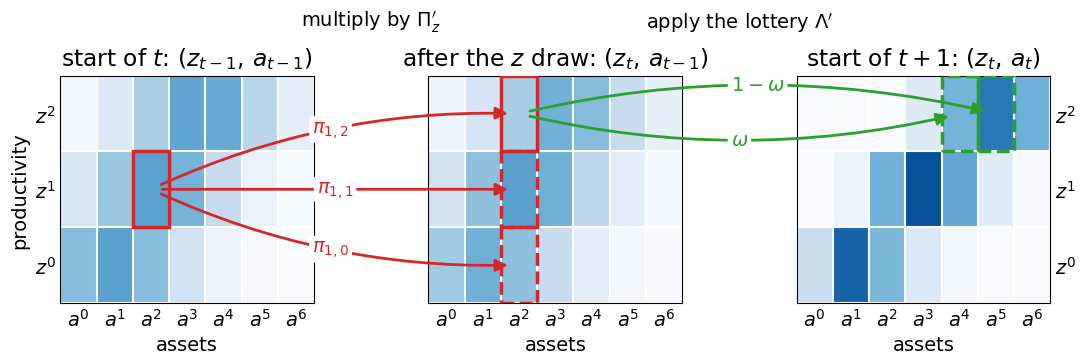

In [16]:
# a. a toy version of the model: 3 productivity states, 7 asset grid points
par_fig = par._replace(Nz=3,Na=7,z_trans=np.array([[0.80,0.15,0.05],[0.10,0.80,0.10],[0.05,0.15,0.80]]))
i_z_grid,i_a_grid = np.meshgrid(np.arange(3),np.arange(7),indexing='ij')

# b. a made-up policy in grid units, a*(z,a_) rises in both z and a_, and its lottery
a_star_fig = np.clip(0.6*i_a_grid+1.3*i_z_grid+0.4,0,7-1.001)
pol_indices_fig = np.floor(a_star_fig).astype(np.int64)
pol_weights_fig = pol_indices_fig+1-a_star_fig

# c. one period forward with the function above
Dbeg_fig = np.exp(-(i_a_grid-1.0-1.2*i_z_grid)**2/(2*1.4**2))
Dbeg_fig /= Dbeg_fig.sum()
Dbeg_plus_fig = np.zeros_like(Dbeg_fig)
D_fig = simulate_hh_forwards(par_fig,Dbeg_fig,pol_indices_fig,pol_weights_fig,Dbeg_plus_fig)

# d. the cells we follow: (z^1,a^2), then those who draw z^2
i_z0,i_a0,i_z1 = 1,2,2
i_low = pol_indices_fig[i_z1,i_a0]

with plt.rc_context({'font.size':14}):

    fig,axs = plt.subplots(1,3,figsize=(11,3.6))
    fig.subplots_adjust(left=0.06,right=0.96,bottom=0.17,top=0.80,wspace=0.45)

    titles = ['start of $t$: $(z_{t-1},\\,a_{t-1})$','after the $z$ draw: $(z_t,\\,a_{t-1})$','start of $t+1$: $(z_t,\\,a_t)$']
    vmax = 1.15*max(Dbeg_fig.max(),D_fig.max(),Dbeg_plus_fig.max())
    for ax,mat,title in zip(axs,[Dbeg_fig,D_fig,Dbeg_plus_fig],titles):
        ax.imshow(mat,cmap='Blues',vmin=0,vmax=vmax,origin='lower',aspect='auto')
        ax.set_xticks(np.arange(7),[f'$a^{i}$' for i in range(7)])
        ax.set_yticks(np.arange(3),[f'$z^{i}$' for i in range(3)])
        ax.set_xticks(np.arange(-0.5,7),minor=True)
        ax.set_yticks(np.arange(-0.5,3),minor=True)
        ax.grid(which='minor',color='white',linewidth=1.5)
        ax.tick_params(which='both',length=0)
        ax.set_title(title,pad=8)
        ax.set_xlabel('assets')
    axs[0].set_ylabel('productivity')
    axs[1].set_yticklabels([])
    axs[2].yaxis.tick_right()

    def box(ax,i_z,i_a,color,ls='-'):
        """ outline one cell """
        ax.add_patch(Rectangle((i_a-0.5,i_z-0.5),1,1,fill=False,edgecolor=color,linewidth=2.5,linestyle=ls,zorder=5))

    def arrow(ax_from,cell_from,ax_to,cell_to,label,color,rad):
        """ curved arrow between cells of two panels, label at its midpoint """
        to_fig = fig.transFigure.inverted().transform
        p1 = ax_from.transData.transform(cell_from[::-1])
        p2 = ax_to.transData.transform(cell_to[::-1])
        fig.add_artist(FancyArrowPatch(to_fig(p1),to_fig(p2),transform=fig.transFigure,arrowstyle='-|>',mutation_scale=18,
                                       color=color,linewidth=2,connectionstyle=f'arc3,rad={rad}',shrinkA=8,shrinkB=8,zorder=10))
        mid = 0.5*(p1+p2) + 0.5*rad*np.array([p2[1]-p1[1],p1[0]-p2[0]])
        fig.text(*to_fig(mid),label,color=color,ha='center',va='center',zorder=11,bbox=dict(boxstyle='round,pad=0.15',facecolor='white',edgecolor='none'))

    # e. productivity draw: the mass at (z^1,a^2) is spread over the column a^2
    box(axs[0],i_z0,i_a0,'C3')
    for i_z,rad in zip(range(3),[0.12,0.0,-0.12]):
        box(axs[1],i_z,i_a0,'C3',ls='-' if i_z == i_z1 else '--')
        arrow(axs[0],(i_z0,i_a0),axs[1],(i_z,i_a0),f'$\\pi_{{{i_z0},{i_z}}}$','C3',rad)

    # f. savings lottery: those who drew z^2 move along the row, to the two neighbors of a*
    box(axs[2],i_z1,i_low,'C2',ls='--')
    box(axs[2],i_z1,i_low+1,'C2',ls='--')
    arrow(axs[1],(i_z1,i_a0),axs[2],(i_z1,i_low),'$\\omega$','C2',0.12)
    arrow(axs[1],(i_z1,i_a0),axs[2],(i_z1,i_low+1),'$1-\\omega$','C2',-0.12)

    # g. step labels between the panels
    for ax_left,ax_right,text in [(axs[0],axs[1],'multiply by $\\Pi_z^{\\prime}$'),(axs[1],axs[2],'apply the lottery $\\Lambda^{\\prime}$')]:
        fig.text(0.5*(ax_left.get_position().x1+ax_right.get_position().x0),0.95,text,ha='center',va='center')

    fig.savefig('figs/sim_young_method.pdf')
    plt.show()

Apply it once to our initial distribution and see where the mass went.

In [17]:
Dbeg_plus = np.zeros_like(Dbeg)
D = simulate_hh_forwards(par,Dbeg,pol_indices,pol_weights,Dbeg_plus)

print('total mass:',np.sum(Dbeg_plus))
print('grid points with positive mass:',np.sum(Dbeg_plus.sum(axis=0) > 0),'of',par.Na)
print('mass still at a = 0:',np.round(np.sum(Dbeg_plus[:,0]),4))

total mass: 0.9999999999999999
grid points with positive mass: 8 of 300
mass still at a = 0: 0.3839


In one period the mass has spread from a single point to a handful: the low-productivity households stay at the constraint, the others save and land on the first grid points, split by the lottery.

### Iterating

Now iterate.
We plot the CDF of assets after a few different numbers of periods.

simulation time: 0.01 secs


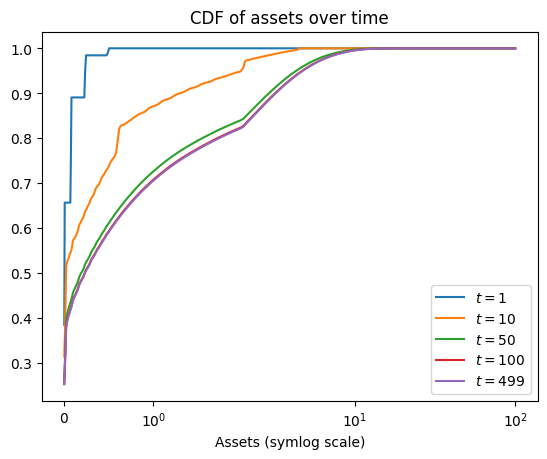

In [18]:
# a. initial distribution: all mass at a = 0
Dbeg = np.zeros((par.Nz,par.Na))
Dbeg[:,0] = par.z_ergodic
Dbeg_plus = np.zeros_like(Dbeg)

# b. iterate forward, plotting snapshots
t0 = time.time()
for t in range(T_sim):

    if t in [1,10,50,100,T_sim-1]:
        plt.plot(par.a_grid,np.cumsum(Dbeg.sum(axis=0)),label=f'$t = {t}$')

    simulate_hh_forwards(par,Dbeg,pol_indices,pol_weights,Dbeg_plus)
    Dbeg,Dbeg_plus = Dbeg_plus,Dbeg

print(f'simulation time: {time.time()-t0:.2f} secs')

plt.xscale('symlog')
plt.title('CDF of assets over time')
plt.xlabel('Assets (symlog scale)')
plt.legend()
plt.savefig('figs/sim_dist_convergence.pdf')
plt.show()

Same $T$ as the Monte Carlo, a fraction of the time, and each period is *exact* given the previous
distribution. The distribution converges: after a few hundred periods the CDF stops moving. As with the policy
functions, we can make that the stopping rule and iterate to the **stationary distribution**:

In [19]:
def simulate_hh_ss(par,pol_indices,pol_weights,max_iter=100_000,tol=1e-13):
    """ iterate the forward step until the distribution stops moving """

    Dbeg = np.zeros((par.Nz,par.Na))
    Dbeg[:,0] = par.z_ergodic
    Dbeg_plus = np.zeros_like(Dbeg)

    for it in range(max_iter):

        D = simulate_hh_forwards(par,Dbeg,pol_indices,pol_weights,Dbeg_plus)

        if np.max(np.abs(Dbeg_plus-Dbeg)) < tol: break
        Dbeg,Dbeg_plus = Dbeg_plus,Dbeg

    return Dbeg_plus,D,it

t0 = time.time()
Dbeg_ss,D_ss,it = simulate_hh_ss(par,pol_indices,pol_weights)
print(f'converged in {it} iterations, {time.time()-t0:.2f} secs')
print(f'total mass: {np.sum(Dbeg_ss):.12f}')
print(f'mass at the top of the grid: {np.sum(Dbeg_ss[:,-1]):.2e}')

converged in 526 iterations, 0.01 secs
total mass: 1.000000000000
mass at the top of the grid: 0.00e+00


The mass sums to one, so no household was lost in the lotteries.
And there is no mass at the top of the grid.
Always check that: if households pile up at $\bar{a}$, the grid is too short and the lottery is silently truncating their savings.

Does it agree with the Monte Carlo? Compare the CDF of end-of-period assets: the empirical CDF of the simulated
cross-section against the cumulative sum of the histogram.

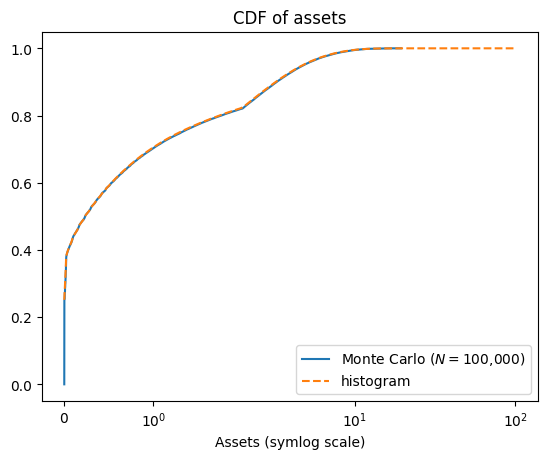

In [20]:
plt.plot(np.sort(a_sim),np.linspace(0,1,a_sim.size),label='Monte Carlo ($N = 100{,}000$)')
plt.plot(par.a_grid,np.cumsum(Dbeg_ss.sum(axis=0)),'--',label='histogram')
plt.xscale('symlog')
plt.title('CDF of assets')
plt.xlabel('Assets (symlog scale)')
plt.legend()
plt.savefig('figs/sim_mc_vs_hist.pdf')
plt.show()

- The two methods agree on the distribution. 
- One caveat: the histogram lives *on the grid*. Each policy function value is replaced by a two-point lottery, so
the distribution is only as fine as $\mathcal{G}_a$

## Aggregation

With the distribution in hand, aggregates are sums over the grid,

$$
A^{hh} = \sum_{i_z}\sum_{i_{a-}} \boldsymbol{D}(z^{i_z},a^{i_{a-}}) \, a^*(z^{i_z},a^{i_{a-}}), \qquad
C^{hh} = \sum_{i_z}\sum_{i_{a-}} \boldsymbol{D}(z^{i_z},a^{i_{a-}}) \, c^*(z^{i_z},a^{i_{a-}})
$$

where $\boldsymbol{D} = \Pi_z' \underline{\boldsymbol{D}}$ is the distribution *after* the productivity draw,
so it lines up with the states the policy functions are indexed by.

In [21]:
A_hh = np.sum(D_ss*a)
C_hh = np.sum(D_ss*c)

print(f'A_hh (histogram):   {A_hh:.4f}')
print(f'A_hh (Monte Carlo): {A_t[-1]:.4f}')
print(f'C_hh (histogram):   {C_hh:.4f}')

A_hh (histogram):   1.0501
A_hh (Monte Carlo): 1.0528
C_hh (histogram):   1.0210


Two checks. In the stationary distribution, aggregating the budget constraint gives
$C^{hh} = r A^{hh} + w$, since $\mathbb{E}[z] = 1$ and aggregate assets are constant:

In [22]:
print(f'C_hh:        {C_hh:.8f}')
print(f'r*A_hh + w:  {par.r*A_hh + par.w:.8f}')

C_hh:        1.02100258
r*A_hh + w:  1.02100258


And the aggregate MPC. In lecture 02 the PIH said around $2\%$; the data said $40$-$50\%$. What does the model
say? Weight the MPC at each grid point by the mass of households sitting there:

In [23]:
MPC = np.zeros((par.Nz,par.Na))
MPC[:,:-1] = (c[:,1:]-c[:,:-1])/((1+par.r)*(par.a_grid[1:]-par.a_grid[:-1]))
MPC[:,-1] = MPC[:,-2]

MPC_hh = np.sum(D_ss*MPC)
print(f'aggregate MPC: {MPC_hh:.3f}')
print(f'PIH, r/(1+r):  {par.r/(1+par.r):.3f}')

aggregate MPC: 0.326
PIH, r/(1+r):  0.020


The aggregate MPC is an order of magnitude above the PIH, because a lot of mass sits at low asset levels where
the MPC is high. This number is a property of the *distribution*, not of any single household, which is exactly
why we needed this notebook.

## Exercise: death

Households so far live forever.
Add a *perpetual youth* structure: at the end of each period, after saving, a household dies with probability $\delta = 0.02$, an expected lifetime of 50 years.
It is replaced by a newborn with no assets, $a = 0$, and productivity drawn from the ergodic distribution.
There are no annuities: the assets of the dead are lost.

1. **Backward.** Survival discounts the future, so the Euler-equation becomes $u'(c_t) = \beta(1-\delta)(1+r)\,\mathbb{E}_t[u'(c_{t+1})]$. This needs no new code: build `par_death` with `par._replace(beta=...)` and call `solve_hh_ss`.
2. **Forward.** Write `simulate_hh_forwards_death`: the same two steps as `simulate_hh_forwards` plus a third one for death. Think about *where* it goes, and check that the distribution still sums to one.
3. Iterate to the stationary distribution, as in `simulate_hh_ss`. Plot the CDF of assets with and without death, and compare $A^{hh}$ and $C^{hh}$.
4. The check $C^{hh} = rA^{hh} + w$ now fails. Derive the identity that replaces it, with $A^{hh} = \sum \boldsymbol{D}\,a^{\ast}$ still the *end-of-period* assets, and check it numerically.

In [24]:
delta = 0.02

@nb.njit
def simulate_hh_forwards_death(par,delta,Dbeg,pol_indices,pol_weights,Dbeg_plus):
    """ one period forward: productivity transition, savings lottery, then death """

    # a. productivity transition

    # b. savings lottery

    # c. death

    pass

In [25]:
# solve with death, iterate to the stationary distribution, compare, check the budget identity


## Answers

In [26]:
par_death = par._replace(beta=par.beta*(1-delta))
c_death,a_death,_ = solve_hh_ss(par_death,par.r,par.w)

In [27]:
@nb.njit
def simulate_hh_forwards_death(par,delta,Dbeg,pol_indices,pol_weights,Dbeg_plus):
    """ one period forward: productivity transition, savings lottery, then death """

    # a. productivity transition
    D = par.z_trans.T@Dbeg

    # b. savings lottery
    Dbeg_plus[:] = 0.0
    for i_z in range(par.Nz):
        for i_a in range(par.Na):

            i = pol_indices[i_z,i_a]
            omega = pol_weights[i_z,i_a]
            Dbeg_plus[i_z,i] += omega*D[i_z,i_a]
            Dbeg_plus[i_z,i+1] += (1-omega)*D[i_z,i_a]

    # c. death: survivors keep their assets, newborns start at zero with ergodic productivity
    Dbeg_plus[:] *= 1-delta
    Dbeg_plus[:,0] += delta*par.z_ergodic

    return D

Death comes *after* the lottery: it acts on end-of-period assets, once saving is done.
Putting it before would let the newborn choose savings in the period of birth from the state of the dead household.

converged in 206 iterations, total mass: 1.000000000000


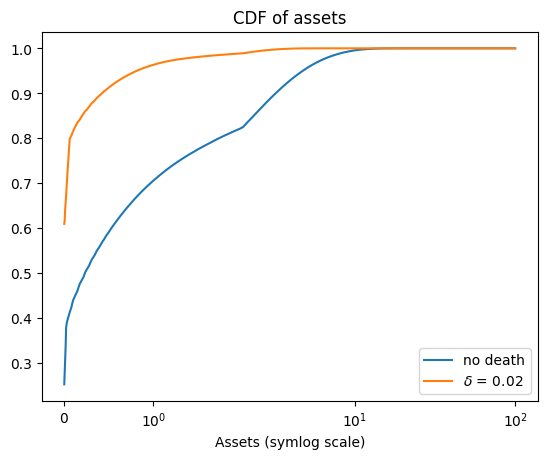

A_hh: 1.0501 without death, 0.1402 with death
C_hh: 1.0210 without death, 0.9999 with death


In [28]:
# a. lottery from the new policy function
pol_indices_death = np.zeros((par.Nz,par.Na),dtype=np.int64)
pol_weights_death = np.zeros((par.Nz,par.Na))
for i_z in range(par.Nz):
    i = np.searchsorted(par.a_grid,a_death[i_z],side='right') - 1
    i = np.clip(i,0,par.Na-2)
    pol_indices_death[i_z] = i
    pol_weights_death[i_z] = (par.a_grid[i+1]-a_death[i_z])/(par.a_grid[i+1]-par.a_grid[i])

# b. stationary distribution
Dbeg = np.zeros((par.Nz,par.Na))
Dbeg[:,0] = par.z_ergodic
Dbeg_plus = np.zeros_like(Dbeg)

for it in range(100_000):

    D = simulate_hh_forwards_death(par,delta,Dbeg,pol_indices_death,pol_weights_death,Dbeg_plus)

    if np.max(np.abs(Dbeg_plus-Dbeg)) < 1e-13: break
    Dbeg,Dbeg_plus = Dbeg_plus,Dbeg

Dbeg_ss_death,D_ss_death = Dbeg_plus,D
print(f'converged in {it} iterations, total mass: {np.sum(Dbeg_ss_death):.12f}')

# c. compare
plt.plot(par.a_grid,np.cumsum(Dbeg_ss.sum(axis=0)),label='no death')
plt.plot(par.a_grid,np.cumsum(Dbeg_ss_death.sum(axis=0)),label=f'$\\delta$ = {delta}')
plt.xscale('symlog')
plt.title('CDF of assets')
plt.xlabel('Assets (symlog scale)')
plt.legend()
plt.show()

A_hh_death = np.sum(D_ss_death*a_death)
C_hh_death = np.sum(D_ss_death*c_death)
print(f'A_hh: {A_hh:.4f} without death, {A_hh_death:.4f} with death')
print(f'C_hh: {C_hh:.4f} without death, {C_hh_death:.4f} with death')

Wealth falls a lot.
Two reasons, both pushing the same way: households discount the future more, $\beta(1-\delta)(1+r) = 0.94$ instead of $0.98$, so the buffer-stock target is lower, and every period two percent of the wealth stock is destroyed and replaced by newborns with nothing.

**The budget identity.** Beginning-of-period assets are what the survivors carried over, $(1-\delta)A^{hh}$, so aggregating the budget constraints in the stationary distribution gives

$$
C^{hh} = (1+r)(1-\delta)A^{hh} + w - A^{hh} = w + \left[r - \delta(1+r)\right]A^{hh}
$$

The missing $\delta(1+r)A^{hh}$ is the wealth of the dead, which disappears from the economy.
With annuities it would be redistributed to the survivors as a higher return, which is the Blanchard (1985) version.

In [29]:
print(f'C_hh:                       {C_hh_death:.8f}')
print(f'r*A_hh + w:                 {par.r*A_hh_death + par.w:.8f}')
print(f'(r - delta*(1+r))*A_hh + w: {(par.r-delta*(1+par.r))*A_hh_death + par.w:.8f}')

C_hh:                       0.99994393
r*A_hh + w:                 1.00280343
(r - delta*(1+r))*A_hh + w: 0.99994393


## Summary

Solving the household block is now a fixed two-step recipe:

1. **Backward:** iterate `solve_hh_backwards` (EGM) until the policy functions converge.
2. **Forward:** build the lottery, iterate `simulate_hh_forwards` (histogram) until the distribution converges.
3. **Aggregate:** $A^{hh} = \sum \boldsymbol{D} \, a^*$ and $C^{hh} = \sum \boldsymbol{D} \, c^*$.

Everything is deterministic, fast, and exact up to the grids. In the next lecture `GEModelTools` runs precisely
this recipe for us, and the prices $r$ and $w$, fixed here, become equilibrium objects that make the aggregates
consistent with firms and market clearing.